In [1]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.optimize import fsolve
import math

In [ ]:
# 1. Define a scaling range for N

node_sizes = np.arange(100, 10001, 200)
n_iter = 10

subcritical_sizes = []
critical_sizes = []
supercritical_sizes = []

print("Simulating scaling bounds...")
for n in node_sizes:
    sub_buffer = []
    critical_buffer = []
    super_buffer = []

    for _ in range(n_iter):
        # Subcritical: np = 0.5 (Should be O(log n))
        G_sub = nx.erdos_renyi_graph(n, p=0.5/n)
        if len(G_sub) > 0 and not nx.is_empty(G_sub):
            sub_buffer.append(len(max(nx.connected_components(G_sub), key=len)))
        else:
            sub_buffer.append(0)

        # Critical: np = 1.0 (Should be O(n^(2/3)))
        G_critical = nx.erdos_renyi_graph(n, p=1.0/n)
        critical_buffer.append(len(max(nx.connected_components(G_critical), key=len)))
            
        # Supercritical: np = 2.0 (Should be Theta(n))
        G_super = nx.erdos_renyi_graph(n, p=2.0/n)
        super_buffer.append(len(max(nx.connected_components(G_super), key=len)))
        
    subcritical_sizes.append(np.mean(sub_buffer))
    critical_sizes.append(np.mean(critical_buffer))
    supercritical_sizes.append(np.mean(super_buffer))



Simulating scaling bounds...


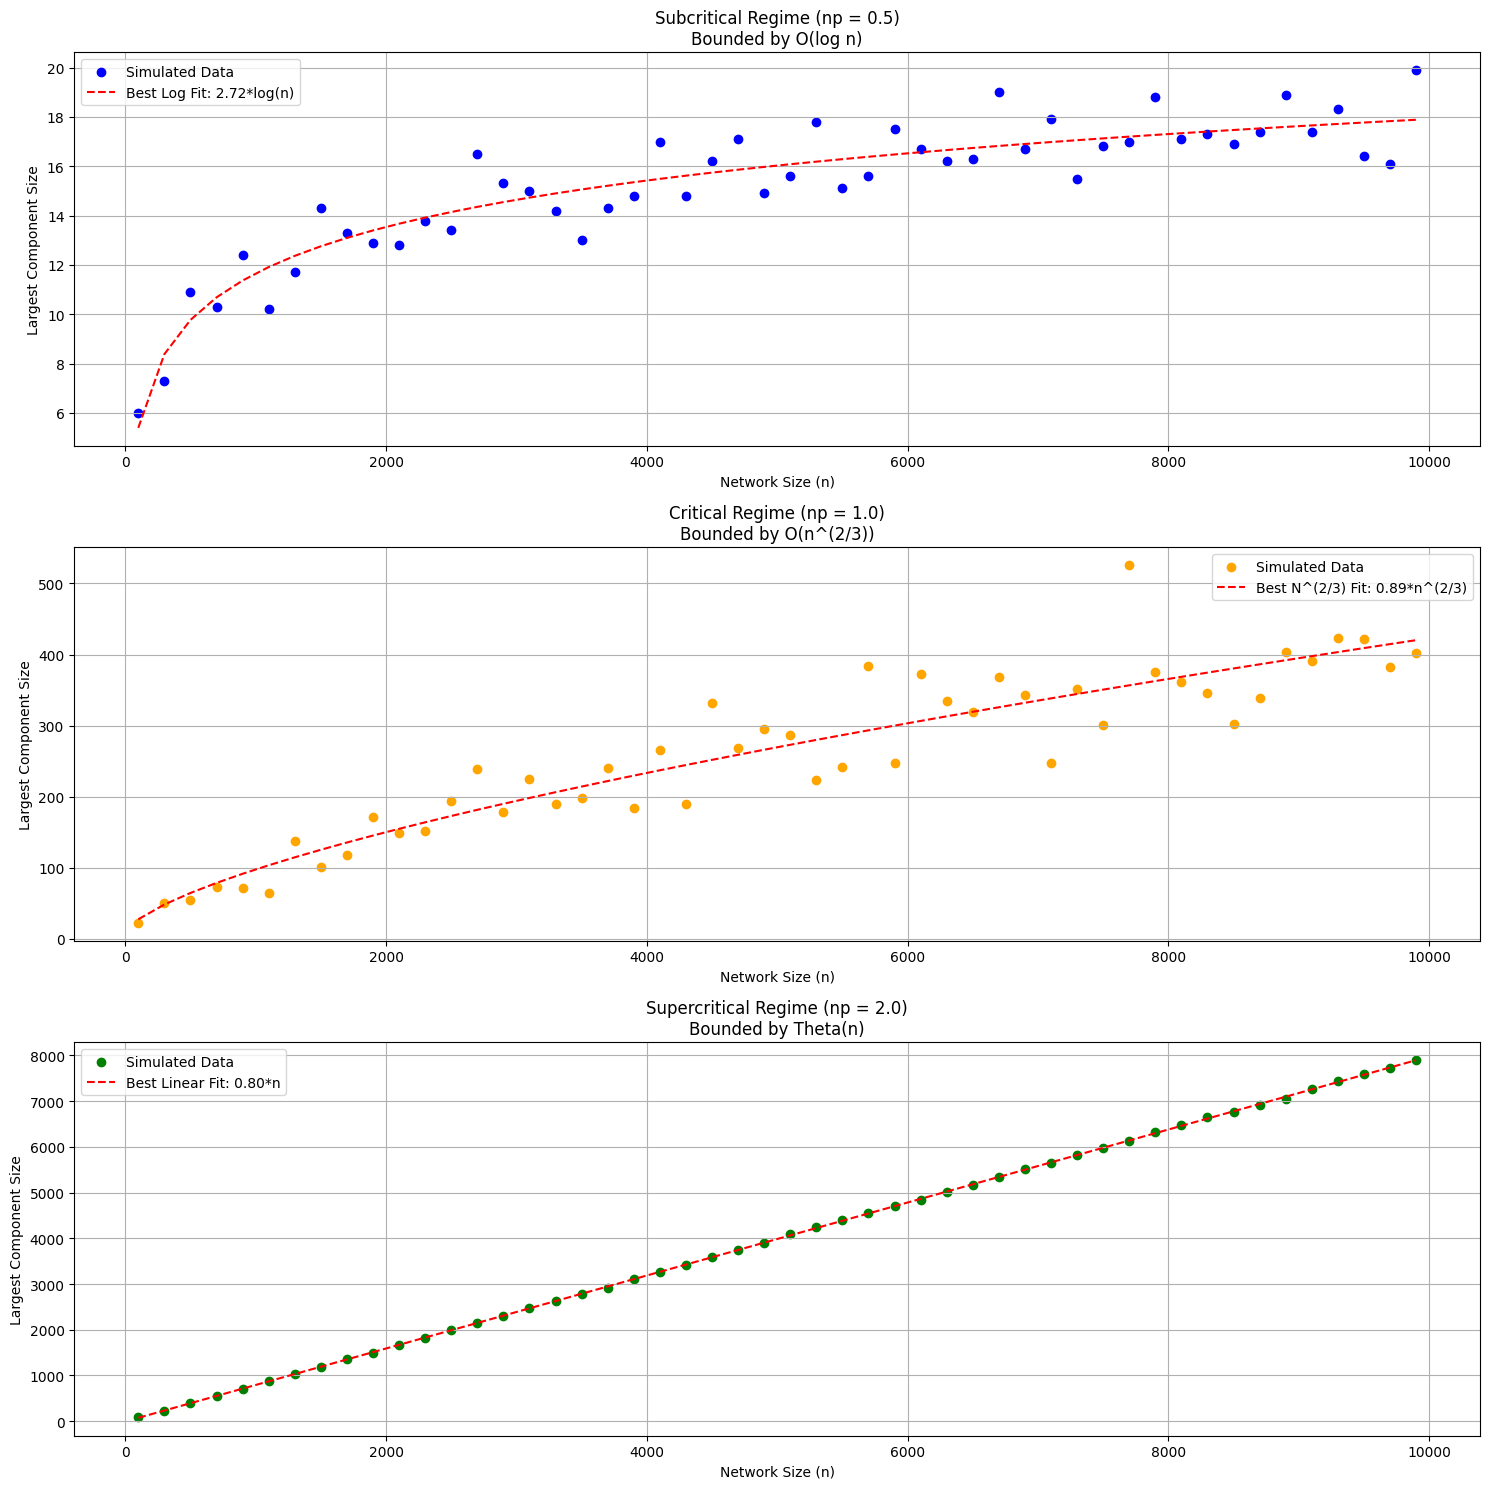

In [13]:
# --- 2. MATHEMATICAL PROOF (Curve Fitting) ---

# Ideal theoretical functions
def log_func(x, a, b): return a * np.log(x) + b

def n_pow_2_3_func(x, a, b): return a * np.power(x, 2/3) + b

def linear_func(x, a, b): return a * x + b

# Fit the simulated data to the expected math models
popt_sub, _ = curve_fit(log_func, node_sizes, subcritical_sizes)
popt_critical, _ = curve_fit(n_pow_2_3_func, node_sizes, critical_sizes)
popt_super, _ = curve_fit(linear_func, node_sizes, supercritical_sizes)

# --- 3. VISUALIZATION ---
plt.figure(figsize=(15, 15))

# Plot Subcritical Regime
plt.subplot(3, 1, 1)
plt.scatter(node_sizes, subcritical_sizes, color='blue', label='Simulated Data')
plt.plot(node_sizes, log_func(node_sizes, *popt_sub), 'r--', 
         label=f'Best Log Fit: {popt_sub[0]:.2f}*log(n)')
plt.title('Subcritical Regime (np = 0.5)\nBounded by O(log n)')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

# Plot Critical Regime
plt.subplot(3, 1, 2)
plt.scatter(node_sizes, critical_sizes, color='orange', label='Simulated Data')
plt.plot(node_sizes, n_pow_2_3_func(node_sizes, *popt_critical), 'r--', 
         label=f'Best N^(2/3) Fit: {popt_critical[0]:.2f}*n^(2/3)')
plt.title('Critical Regime (np = 1.0)\nBounded by O(n^(2/3))')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

# Plot Supercritical Regime
plt.subplot(3, 1, 3)
plt.scatter(node_sizes, supercritical_sizes, color='green', label='Simulated Data')
plt.plot(node_sizes, linear_func(node_sizes, *popt_super), 'r--', 
         label=f'Best Linear Fit: {popt_super[0]:.2f}*n')
plt.title('Supercritical Regime (np = 2.0)\nBounded by Theta(n)')
plt.xlabel('Network Size (n)')
plt.ylabel('Largest Component Size')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

In [14]:
df = pd.DataFrame({
    'Node Size': node_sizes,
    'Subcritical (np=0.5)': subcritical_sizes,
    'Critical (np=1.0)': critical_sizes,
    'Supercritical (np=2.0)': supercritical_sizes
})

df["Node Size"] = df["Node Size"].astype(int)
df[["Subcritical (np=0.5)", "Critical (np=1.0)", "Supercritical (np=2.0)"]] = df[["Subcritical (np=0.5)", "Critical (np=1.0)", "Supercritical (np=2.0)"]].astype(float)
df.to_parquet("giant_component_scaling_bounds.parquet", engine='fastparquet', index=False)


Running simulation for n = 100...
Running simulation for n = 500...
Running simulation for n = 2000...


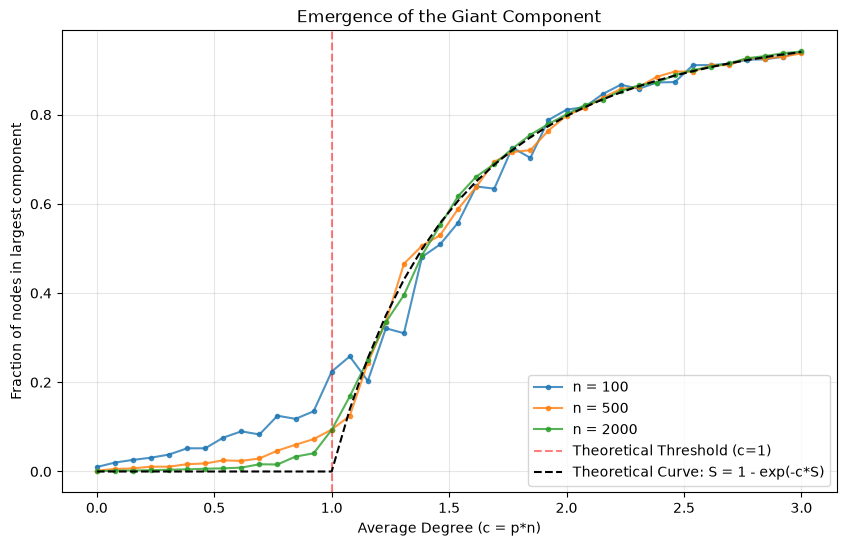

In [ ]:
def simulate_giant_component(n_values, c_values, trials=5):
    """
    Simulates the emergence of the giant component in Erdos-Renyi graphs.
    """
    results = {n: [] for n in n_values}
    
    for n in n_values:
        print(f"Running simulation for n = {n}...")
        for c in c_values:
            p = c / n
            fraction_sum = 0
            
            # Monte Carlo trials to smooth out the curve
            for _ in range(trials):
                # Generate the Erdos-Renyi graph
                G = nx.erdos_renyi_graph(n, p)
                
                # Find the largest connected component
                # Note: max() on connected_components returns the largest set of nodes
                largest_cc = max(nx.connected_components(G), key=len)
                
                # Normalize by total number of nodes n
                fraction_sum += len(largest_cc) / n
                
            # Average the fraction over the trials
            results[n].append(fraction_sum / trials)
            
    return results

# --- Parameters ---
n_values = [100, 500, 2000]       # Different network sizes
c_values = np.linspace(0, 3, 40)  # Sweep c from 0 to 3

# --- Run Simulation ---
data = simulate_giant_component(n_values, c_values, trials=10)


# Include theoretical S = 1 - exp(-c*S) curve for comparison
def theoretical_giant_component(c):
    # Solve S = 1 - exp(-c*S) numerically for each c
    S_values = []
    for c_val in c:
        func = lambda S: S - (1 - np.exp(-c_val * S))
        S_solution, = fsolve(func, 0.5)  # Initial guess of 0.5
        S_values.append(S_solution)
    return np.array(S_values)

# --- Visualization ---
plt.figure(figsize=(10, 6))

for n in n_values:
    plt.plot(c_values, data[n], label=f'n = {n}', marker='.', alpha=0.8)

plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='Theoretical Threshold (c=1)')
plt.plot(c_values, theoretical_giant_component(c_values), 'k--', label='Theoretical Curve: S = 1 - exp(-c*S)')
plt.title('Emergence of the Giant Component')
plt.xlabel('Average Degree (c = p*n)')
plt.ylabel('Fraction of nodes in largest component')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Running simulations...


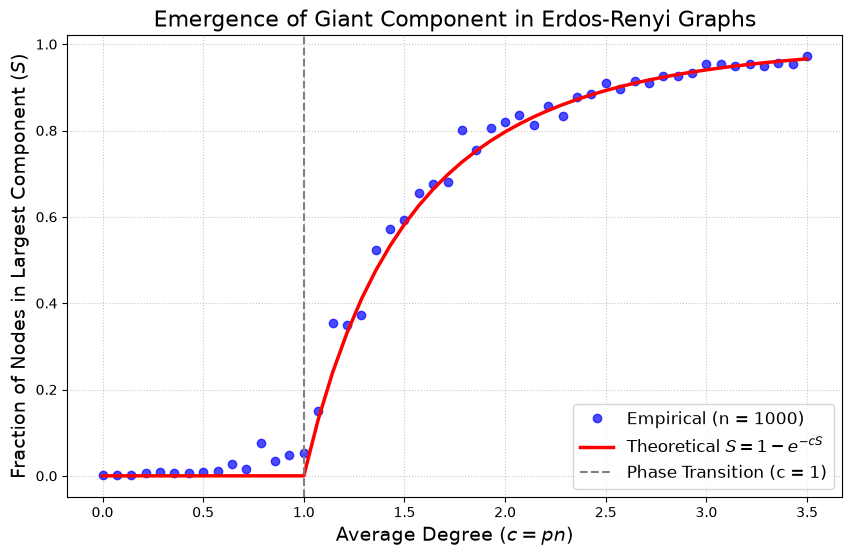

In [3]:
def theoretical_S(c):
    """Derived S value"""
    if c <= 1:
        return 0
    
    func = lambda S: S - 1 + np.exp(-c * S)

    S_solution = fsolve(func, 0.9)[0] # Use 0.9 as an initial guess for S
    return S_solution

n = 1000
"""1000 at roughly 3s, 2000 at roughly 11s, 10000 roughly at 2.5m"""
c_vals = np.linspace(0.0, 3.5, 50) # range of avg degrees to test
empirical_S = []
theoretical_S_vals = []

print("Running simulations...")
for c in c_vals:
    p = c / n

    G = nx.erdos_renyi_graph(n, p)

    largest_cc = max(nx.connected_components(G), key=len)

    empirical_S.append(len(largest_cc) / n)

    theoretical_S_vals.append(theoretical_S(c))

plt.figure(figsize=(10,6))
plt.plot(c_vals, empirical_S, 'o', label = f'Empirical (n = {n})', 
         markersize = 6, alpha = 0.7, color = 'blue')
plt.plot(c_vals, theoretical_S_vals, '-', label = 'Theoretical $S = 1 - e^{-cS}$', color = 'red', linewidth = 2.5)

#phase transitions
plt.axvline(x = 1, color = 'gray', linestyle = '--', label = 'Phase Transition (c = 1)')

plt.title('Emergence of Giant Component in Erdos-Renyi Graphs', fontsize = 16)
plt.xlabel('Average Degree ($c = pn$)', fontsize = 14)
plt.ylabel('Fraction of Nodes in Largest Component ($S$)', fontsize = 14)
plt.legend(fontsize = 12)
plt.grid(True, linestyle = ':', alpha = 0.7)

plt.show()

--- Analyzing Phase 3 (n=500, c=1.2) ---
Total Edges (N): 600

--- The Giant Component ---
Theoretical Size (G(c)*n): ~439 vertices
Actual Simulated Size:     450 vertices
Percentage of Graph:       90.0%

--- The 'Melting' Process (Small Trees) ---
Theoretical Total Components: ~51
Actual Total Components:      44
Number of 'surviving' disconnected clusters: 43


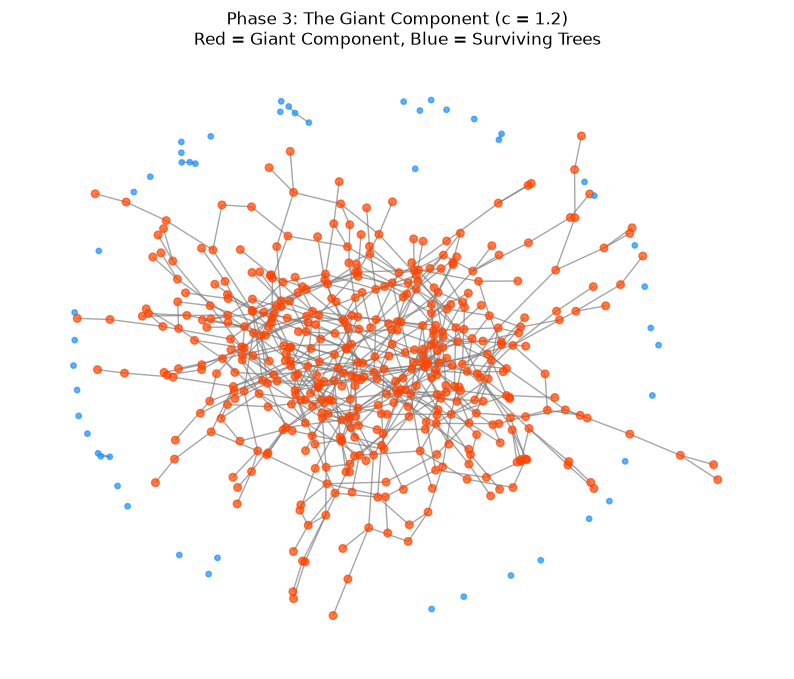

In [ ]:
def theoretical_giant_size(c):
    """
    Calculates the theoretical fraction G(c) of vertices in the giant component.
    Uses the implicit equation G = 1 - exp(-2cG) which is mathematically 
    equivalent to the infinite series provided in the paper.
    """
    if c <= 0.5:
        return 0.0
    # Solve G = 1 - exp(-2cG) for G
    func = lambda G: G - (1 - np.exp(-2 * c * G))
    # Initial guess: 0.9 if c is large, else a small positive number
    G_solution = fsolve(func, 0.5)[0]
    return G_solution

def theoretical_component_count(n, c, G_c):
    """
    Calculates the theoretical total number of components for c > 1/2.
    Formula: (n / 2c) * (X(c) - X(c)^2 / 2) where X(c) = 2c(1 - G(c))
    """
    X_c = 2 * c * (1 - G_c)
    return (n / (2 * c)) * (X_c - (X_c**2) / 2)

def analyze_phase_3(n=500, c=1.2):
    """
    Simulates Phase 3 for a given n (vertices) and c (edge ratio).
    Phase 3 occurs when c > 0.5 (N ~ cn).
    """
    print(f"--- Analyzing Phase 3 (n={n}, c={c}) ---")
    N = int(c * n)
    print(f"Total Edges (N): {N}")
    
    # 1. Generate the Random Graph
    G = nx.gnm_random_graph(n, N)
    
    # 2. Identify Components
    components = sorted(nx.connected_components(G), key=len, reverse=True)
    giant_component = components[0]
    actual_giant_size = len(giant_component)
    actual_total_components = len(components)
    
    # 3. Theoretical Calculations
    G_c = theoretical_giant_size(c)
    expected_giant_size = G_c * n
    expected_components = theoretical_component_count(n, c, G_c)
    
    # 4. Print the In-Depth Comparison
    print("\n--- The Giant Component ---")
    print(f"Theoretical Size (G(c)*n): ~{int(expected_giant_size)} vertices")
    print(f"Actual Simulated Size:     {actual_giant_size} vertices")
    print(f"Percentage of Graph:       {(actual_giant_size/n)*100:.1f}%")
    
    print("\n--- The 'Melting' Process (Small Trees) ---")
    print(f"Theoretical Total Components: ~{int(expected_components)}")
    print(f"Actual Total Components:      {actual_total_components}")
    print(f"Number of 'surviving' disconnected clusters: {actual_total_components - 1}")
    
    # 5. Visualizing the structure
    colors = ['#FF4500' if node in giant_component else '#1E90FF' for node in G.nodes()]
    sizes = [30 if node in giant_component else 15 for node in G.nodes()]
    
    plt.figure(figsize=(10, 8))
    plt.title(f"Phase 3: The Giant Component (c = {c})\nRed = Giant Component, Blue = Surviving Trees")
    
    # Spring layout pushes disconnected components to the edges naturally
    pos = nx.spring_layout(G, k=0.15, iterations=20, seed=42)
    nx.draw(G, pos, node_size=sizes, node_color=colors, edge_color='gray', 
            alpha=0.7, with_labels=False)
    
    plt.show()

analyze_phase_3(n=500, c=1.2)

--- Running Monte Carlo Simulation for Phase 3 ---
Vertices (n): 5000 | Edge Ratio (c): 1.2 | Trials: 20000
Completed 50/20000 trials...
Completed 100/20000 trials...
Completed 150/20000 trials...
Completed 200/20000 trials...
Completed 250/20000 trials...
Completed 300/20000 trials...
Completed 350/20000 trials...
Completed 400/20000 trials...
Completed 450/20000 trials...
Completed 500/20000 trials...
Completed 550/20000 trials...
Completed 600/20000 trials...
Completed 650/20000 trials...
Completed 700/20000 trials...
Completed 750/20000 trials...
Completed 800/20000 trials...
Completed 850/20000 trials...
Completed 900/20000 trials...
Completed 950/20000 trials...
Completed 1000/20000 trials...
Completed 1050/20000 trials...
Completed 1100/20000 trials...
Completed 1150/20000 trials...
Completed 1200/20000 trials...
Completed 1250/20000 trials...
Completed 1300/20000 trials...
Completed 1350/20000 trials...
Completed 1400/20000 trials...
Completed 1450/20000 trials...
Completed 150

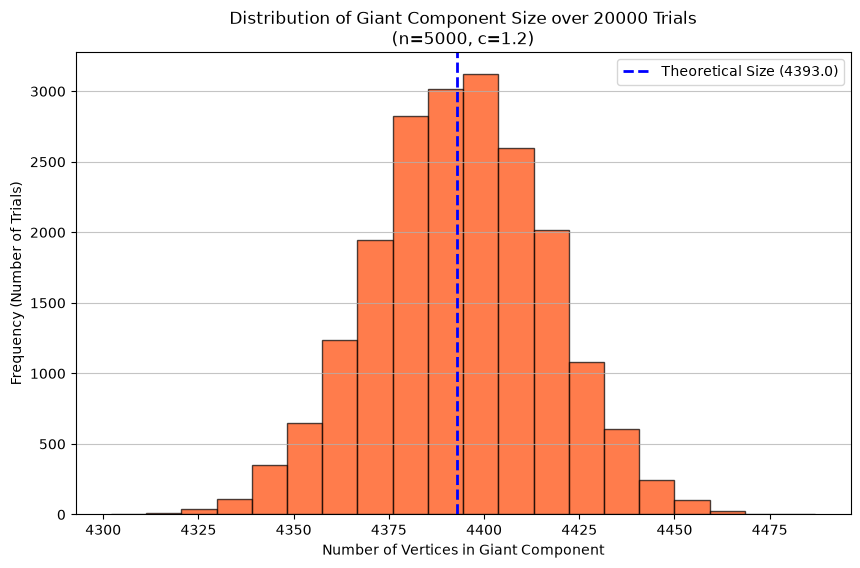

In [15]:
def theoretical_giant_size(c):
    """Calculates the theoretical fraction G(c) of vertices in the giant component."""
    if c <= 0.5:
        return 0.0
    func = lambda G: G - (1 - np.exp(-2 * c * G))
    return fsolve(func, 0.5)[0]

def theoretical_component_count(n, c, G_c):
    """Calculates the theoretical total number of components."""
    X_c = 2 * c * (1 - G_c)
    return (n / (2 * c)) * (X_c - (X_c**2) / 2)

n = 5000
c = 1.2
trials = 20000

def run_phase3_monte_carlo(n, c, trials):
    """
    Runs a Monte Carlo simulation for Phase 3 to collect data 
    on the giant component size and total components over many trials.
    """
    print(f"--- Running Monte Carlo Simulation for Phase 3 ---")
    print(f"Vertices (n): {n} | Edge Ratio (c): {c} | Trials: {trials}")
    
    N = int(c * n)
    G_c = theoretical_giant_size(c)
    expected_giant_size = G_c * n
    expected_components = theoretical_component_count(n, c, G_c)
    
    # Data collection arrays
    giant_sizes = []
    total_components = []
    
    for i in range(trials):
        # Generate random graph
        G = nx.gnm_random_graph(n, N)
        
        # Extract metrics
        components = sorted(nx.connected_components(G), key=len, reverse=True)
        giant_sizes.append(len(components[0]))
        total_components.append(len(components))
        
        # Simple progress indicator
        if (i + 1) % 50 == 0:
            print(f"Completed {i + 1}/{trials} trials...")

    # Calculate Statistics
    avg_giant = np.mean(giant_sizes)
    std_giant = np.std(giant_sizes)
    avg_comps = np.mean(total_components)
    
    print("\n--- Simulation Results ---")
    print(f"Theoretical Giant Size: ~{expected_giant_size:.1f}")
    print(f"Average Simulated Size: {avg_giant:.1f} (± {std_giant:.1f})")
    print(f"Theoretical Total Components: ~{expected_components:.1f}")
    print(f"Average Simulated Components: {avg_comps:.1f}")
    
    # Visualization: Histogram of the Giant Component Size
    plt.figure(figsize=(10, 6))
    plt.hist(giant_sizes, bins=20, color='#FF4500', edgecolor='black', alpha=0.7)
    
    # Plot a vertical line for the theoretical prediction
    plt.axvline(expected_giant_size, color='blue', linestyle='dashed', linewidth=2, 
                label=f'Theoretical Size ({expected_giant_size:.1f})')
    
    plt.title(f"Distribution of Giant Component Size over {trials} Trials\n(n={n}, c={c})")
    plt.xlabel("Number of Vertices in Giant Component")
    plt.ylabel("Frequency (Number of Trials)")
    plt.legend()
    plt.grid(axis='y', alpha=0.75)
    
    plt.show()


run_phase3_monte_carlo(n, c, trials)